# Plot Gallery

Every plotting helper in `landau.plot` at default settings, applied to one
shared model system so the figures can be compared directly.

The system is three ideal solutions — `fcc`, `hcp`, `liquid` — ordered by the
temperature at which each becomes stable (fcc lowest, liquid highest). The
endpoint energies and entropies are loosely taken from the visual-review
testplots (`tests/integration/testplots.py`). The numbers carry no physical
meaning; they are chosen to produce a diagram in which all three phases appear.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import landau.phases as ldp
import landau.calculate as ldc
import landau.plot as lpl

Each phase is an `IdealSolution` between an A endpoint (concentration 0) and a
B endpoint (concentration 1). Higher entropy lowers the free energy faster with
temperature, so the high-entropy `liquid` wins at high T while the low-entropy
`fcc` wins at low T.

In [2]:
fcc = ldp.IdealSolution(
    "fcc",
    ldp.LinePhase("fccA", fixed_concentration=0, line_energy=-3.00, line_entropy=1.0 * ldp.kB),
    ldp.LinePhase("fccB", fixed_concentration=1, line_energy=-2.00, line_entropy=1.1 * ldp.kB),
)
hcp = ldp.IdealSolution(
    "hcp",
    ldp.LinePhase("hcpA", fixed_concentration=0, line_energy=-2.975, line_entropy=1.8 * ldp.kB),
    ldp.LinePhase("hcpB", fixed_concentration=1, line_energy=-1.95, line_entropy=1.1 * ldp.kB),
)
liquid = ldp.IdealSolution(
    "liquid",
    ldp.LinePhase("liquidA", fixed_concentration=0, line_energy=-2.75, line_entropy=5.0 * ldp.kB),
    ldp.LinePhase("liquidB", fixed_concentration=1, line_energy=-1.75, line_entropy=4.4 * ldp.kB),
)
phases = [fcc, hcp, liquid]

## Overview

Every two-axis plotting helper at its default settings. The four panels share
the same `phases`: a temperature cut at fixed chemical potential, a chemical
potential cut at fixed temperature, and the two two-dimensional diagrams in
concentration–temperature and chemical-potential–temperature space.

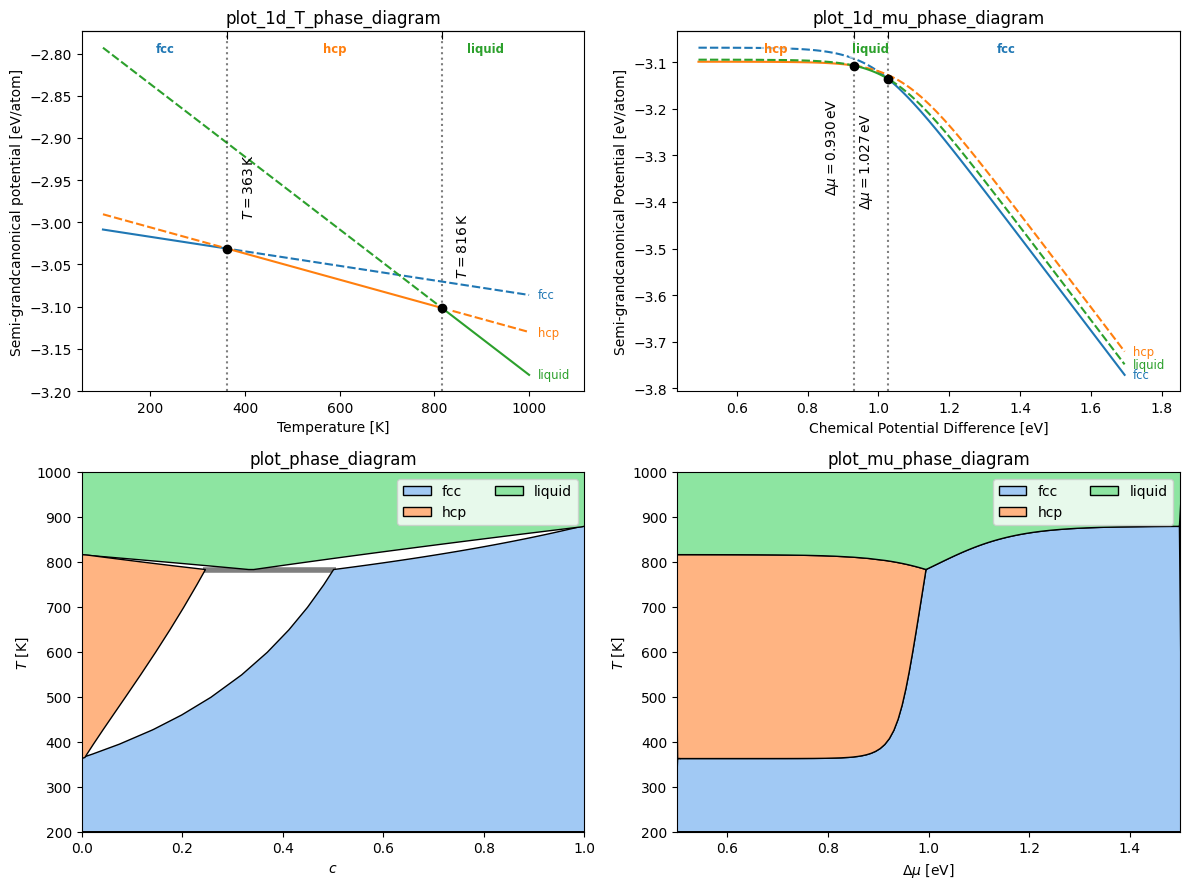

In [3]:
df_T = ldc.calc_phase_diagram(phases, np.linspace(100, 1000, 40), mu=0.0, keep_unstable=True)
df_mu = ldc.calc_phase_diagram(phases, Ts=800.0, mu=100, keep_unstable=True)
df_cT = ldc.calc_phase_diagram(phases, np.linspace(200, 1000, 50), mu=100)
df_muT = ldc.calc_phase_diagram(phases, np.linspace(200, 1000, 80), mu=np.linspace(0.5, 1.5, 80))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
lpl.plot_1d_T_phase_diagram(df_T, ax=axes[0, 0], show=False)
axes[0, 0].set_title("plot_1d_T_phase_diagram")
lpl.plot_1d_mu_phase_diagram(df_mu, ax=axes[0, 1], show=False)
axes[0, 1].set_title("plot_1d_mu_phase_diagram")
lpl.plot_phase_diagram(df_cT, ax=axes[1, 0], tielines=True)
axes[1, 0].set_title("plot_phase_diagram")
lpl.plot_mu_phase_diagram(df_muT, ax=axes[1, 1])
axes[1, 1].set_title("plot_mu_phase_diagram")
fig.tight_layout()

## 1D temperature scan

`plot_1d_T_phase_diagram` draws the semi-grand potential of every phase along a
temperature cut at fixed chemical potential difference. The stable phase is
solid, metastable branches are dashed; transitions are ticked on the top spine
and each branch is labelled at its right end. Pass `keep_unstable=True` to
`calc_phase_diagram` to retain the metastable branches.

<Axes: xlabel='Temperature [K]', ylabel='Semi-grandcanonical potential [eV/atom]'>

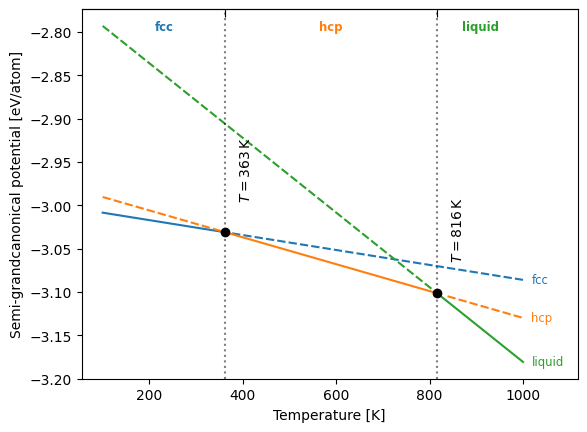

In [4]:
df_T = ldc.calc_phase_diagram(phases, np.linspace(100, 1000, 40), mu=0.0, keep_unstable=True)
lpl.plot_1d_T_phase_diagram(df_T)

`reference_phase` subtracts that phase's potential along the cut, which spreads
out the small differences near the transitions.

<Axes: xlabel='Temperature [K]', ylabel='Semi-grandcanonical potential\nrelative to hcp [eV/atom]'>

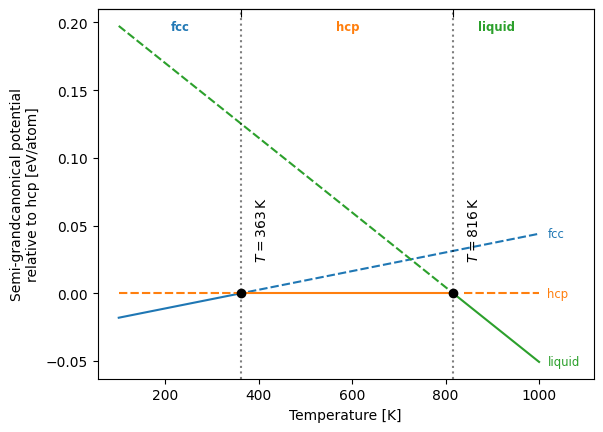

In [5]:
lpl.plot_1d_T_phase_diagram(df_T, reference_phase="hcp")

## 1D chemical-potential scan

`plot_1d_mu_phase_diagram` is the isothermal analogue: the semi-grand potential
along a chemical-potential cut at fixed temperature. Here T = 800 K, where all
three phases are stable over part of the range.

<Axes: xlabel='Chemical Potential Difference [eV]', ylabel='Semi-grandcanonical Potential [eV/atom]'>

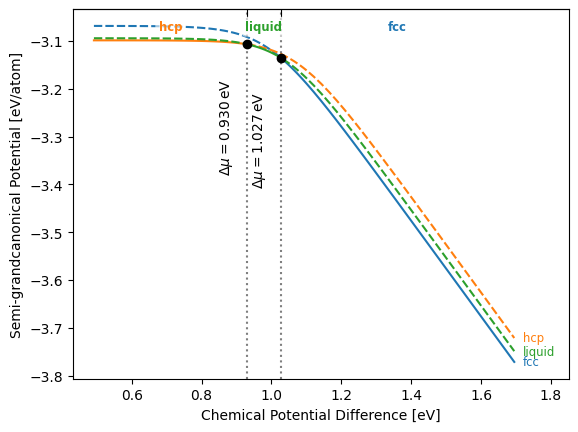

In [6]:
df_mu = ldc.calc_phase_diagram(phases, Ts=800.0, mu=100, keep_unstable=True)
lpl.plot_1d_mu_phase_diagram(df_mu)

<Axes: xlabel='Chemical Potential Difference [eV]', ylabel='Semi-grandcanonical Potential\nrelative to hcp [eV/atom]'>

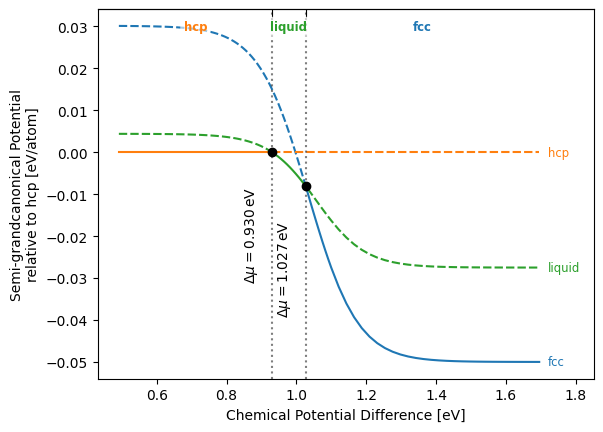

In [7]:
lpl.plot_1d_mu_phase_diagram(df_mu, reference_phase="hcp")

## 2D concentration–temperature diagram

`plot_phase_diagram` fills each stable phase region as a polygon in
concentration–temperature space. `tielines=True` overlays the two-phase
coexistence tielines. `poly_method` selects the polygon-construction strategy;
the default depends on which optional extras are installed.

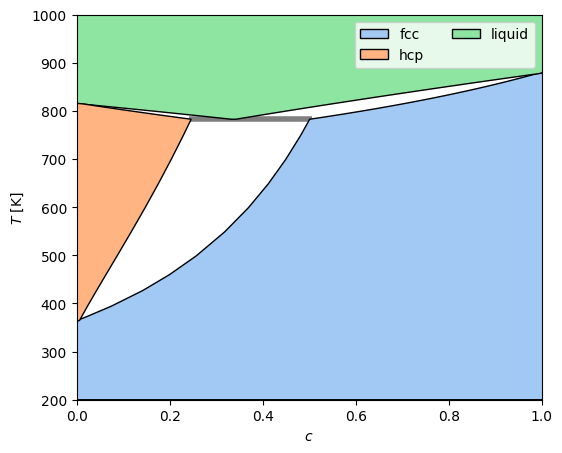

In [8]:
df_cT = ldc.calc_phase_diagram(phases, np.linspace(200, 1000, 50), mu=100)
fig, ax = plt.subplots(figsize=(6, 5))
lpl.plot_phase_diagram(df_cT, ax=ax, tielines=True)

Same diagram without tielines.

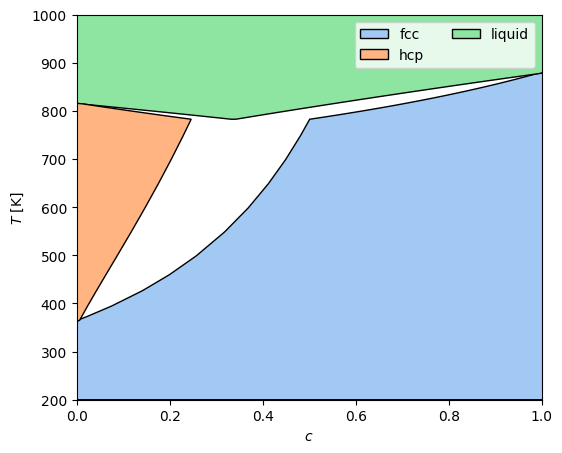

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
lpl.plot_phase_diagram(df_cT, ax=ax, tielines=False)

## 2D chemical-potential–temperature diagram

`plot_mu_phase_diagram` plots the same equilibria in chemical-potential–
temperature space, where the two-phase regions collapse to lines. Sample both
axes so the refiner has a 2D grid to work with.

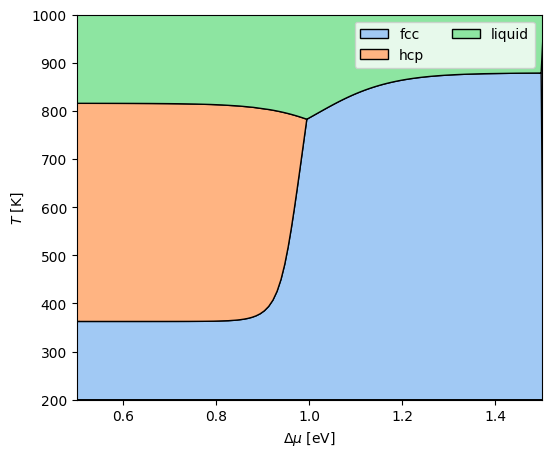

In [10]:
df_muT = ldc.calc_phase_diagram(phases, np.linspace(200, 1000, 80), mu=np.linspace(0.5, 1.5, 80))
fig, ax = plt.subplots(figsize=(6, 5))
lpl.plot_mu_phase_diagram(df_muT, ax=ax)

## Excess free energy

`plot_excess_free_energy` draws the excess free energy versus concentration,
one facet per temperature, from a `keep_unstable=True` frame concatenated over
several temperatures. With `convex_hull=True` the stable phases are solid, the
metastable parts faded, and the common-tangent segments overlaid in black.

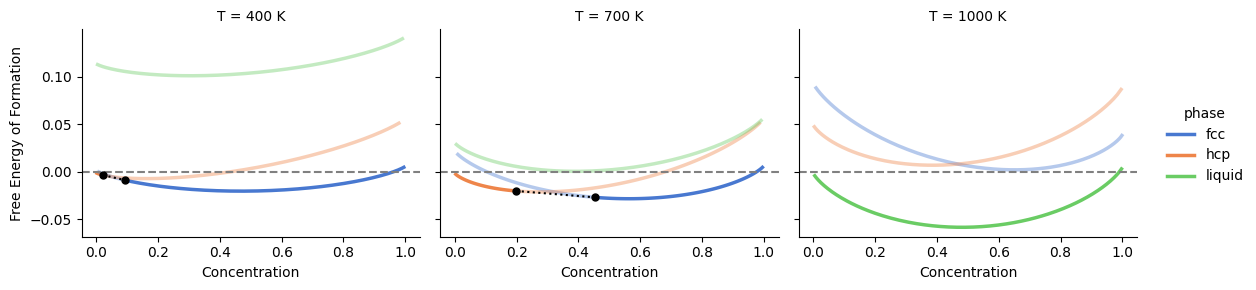

In [11]:
df_excess = pd.concat(
    [ldc.calc_phase_diagram(phases, Ts=T, mu=200, keep_unstable=True) for T in [400, 700, 1000]],
    ignore_index=True,
)
lpl.plot_excess_free_energy(df_excess, convex_hull=True)

## Building polygons by hand

`plot_phase_diagram` is a thin wrapper over `get_polygons` + `plot_polygons`.
Calling them directly gives control over the colour map (via
`get_phase_colors`) and the axes, which is useful when overlaying a phase
diagram on other artists.

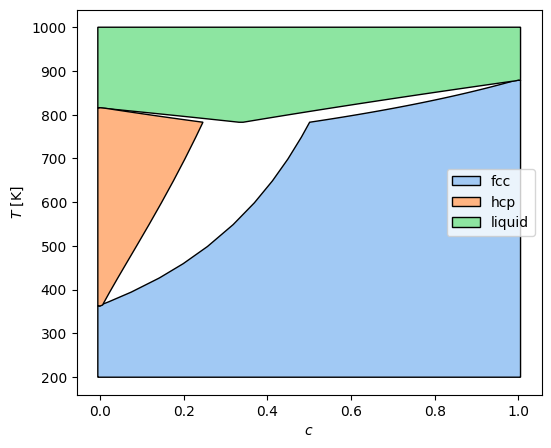

In [12]:
polys = lpl.get_polygons(df_cT)
colors = lpl.get_phase_colors(df_cT["phase"].unique())

fig, ax = plt.subplots(figsize=(6, 5))
lpl.plot_polygons(polys, colors, ax=ax)
ax.autoscale()
ax.set_xlabel("$c$")
ax.set_ylabel("$T$ [K]")
ax.legend()